# Example - Multiparticle tracking optimization

In this notebook, we'll set up an optimization problem. The objective will be to set the BC20 sextupole strengths (symmetrically) to minimize the spot size at PENT

For this demo, we'll start from a reference configuration. To speed up the notebook, CSR is disabled

checkpointElement is used to define the trackStart; since we're only changing elements in BC20, we'll start tracking there instead of tracking the whole lattice

This example is wraps the optimization in Example - Multiparticle tracking optimization in Xopt.  Based on xopt example here: https://xopt.xopt.org/examples/basic/xopt_basic/

In [5]:
import logging

from xopt import Evaluator
from xopt import VOCS
from xopt import Xopt
from xopt.generators import list_available_generators
from xopt.generators import get_generator
import math
from pmd_beamphysics import ParticleGroup

import FACET2_S2E as qs

import numpy as np
import warnings
import pandas as pd

logger = logging.getLogger(__name__)

from pathlib import Path
import os


### Import default settings

In [6]:
filepath = str(Path(os.getcwd()).parent)


importedDefaultSettings = qs.loadConfig("setLattice_configs/2024-10-22_oneBunch_baseline3.yml", filepath)

### Initialize Tao

In [ ]:
csrTF = False
evalElement = "PENT"

inputBeamFilePathSuffix = importedDefaultSettings["inputBeamFilePathSuffix"]
bunchCount = importedDefaultSettings["bunchCount"]

tao = qs.initializeTao(
    filePath= filepath,
    inputBeamFilePathSuffix = inputBeamFilePathSuffix,
    
    csrTF = csrTF,
    numMacroParticles=1e3,
    scratchPath = "/tmp",
    randomizeFileNames = True
)


#Set aside the initial beam for later reference
qs.trackBeam(tao, filepath, trackEnd = "L0BFEND")
PInit = ParticleGroup(data=tao.bunch_data("L0AFEND"))

#Set lattice to imported config
qs.setLattice(tao, **importedDefaultSettings) 

Environment set to:  /sdf/home/c/cropp/FACET2-S2E
-init /sdf/home/c/cropp/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR off
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /sdf/home/c/cropp/FACET2-S2E/setLattice_configs/defaults.yml
Number of macro particles = 1000.0
Beam created, written to /tmp/beams/activeBeamFile_6941860835342998166.h5, and reinit to tao


### Define simulation and optimization parameters

In [8]:
# targetBunchSpacing is for two-bunch optimization
# targetBunchSpacing = 40e-6



# For some optimizations, it's useful for the tolerances to evolve over time
masterToleranceScalingStart = 1 #Higher is looser; generally tighten for early sims and loosen for refinement
masterToleranceScalingEnd = 1 #masterToleranceScalingStart
masterToleranceScalingEvolutionSteps = 2000
masterToleranceScaling = masterToleranceScalingStart



# Enable or disable different penalty terms
enableAlignmentTerms    = 1                        
    # Enable centroid offset and angle penalties. Useful for removing final focus kickers from free parameters
enableLongitudinalTerms = 1                       
    # Enable bunch spacing penalty and bunch length objectives 
alignmentIsRelative     = 1 and (bunchCount == 2)  
    # Toggle between absolute and relative pointing. Must be absolute for single bunch or stuff breaks
stageOneOptimization    = 0                        
    # Disabling transverse terms and length limits, per https://docs.google.com/presentation/d/1b6WoEwmDz5cA0fm9FbbGiZoMwBcbCNNNCsD7JiFDxRc/edit#slide=id.g2f91233284b_0_0



# If usingCheckpoint, partial tracking is used from checkpointElement to evalElement
# Select the appropriate element based on the active free parameters
usingCheckpoint = True
#checkpointElement = "MFFF"
checkpointElement = "CB1LE" #Shortly downstream of BEGBC20; there's an intervening dipole though
#checkpointElement = "BEGBC20"
#checkpointElement = "HLAM"  #Upstream of Q19851


## Define VOCS
### Define variables first

In [9]:
## Define VOCS

pbounds = {
    # "QA10361kG": eval(importedDefaultSettings["QA10361kGBounds"]),
    # "QA10371kG": eval(importedDefaultSettings["QA10371kGBounds"]),
    # "QE10425kG": eval(importedDefaultSettings["QE10425kGBounds"]),
    # "QE10441kG": eval(importedDefaultSettings["QE10441kGBounds"]),
    # "QE10511kG": eval(importedDefaultSettings["QE10511kGBounds"]),
    # "QE10525kG": eval(importedDefaultSettings["QE10525kGBounds"]),

    # # 'L0BPhaseSet': (-30, 30),
    # 'L1PhaseSet': (-60, 0),
    # 'L2PhaseSet': (-60, 0),
    # 'L3PhaseSet': (-40, 40),
    
    # # # 'L0BEnergyOffset': (-5e6, 5e6),
    # 'L1EnergyOffset': (-20e6, 20e6),
    # 'L2EnergyOffset': (-500e6, 500e6),
    # 'L3EnergyOffset': (-4500e6, -3500e6),

    # "Q19851kG":  eval(importedDefaultSettings["Q19851kGBounds"]),
    # "Q19871kG":  eval(importedDefaultSettings["Q19871kGBounds"]),

    
    # "B1EkG" : (4.4, 4.6),      #(4.0,  5.0),        
    # "B2EkG" : (-6.65, -6.45),  #(-7.0, -6.0),       
    # "B3EkG" : (1.95, 2.15),    #(1.5,  2.5),        
    
    # "Q1EkG":  eval(importedDefaultSettings["Q1EkGBounds"]),
    # "Q2EkG":  eval(importedDefaultSettings["Q2EkGBounds"]),
    # "Q3EkG":  eval(importedDefaultSettings["Q3EkGBounds"]),
    # "Q4EkG":  eval(importedDefaultSettings["Q4EkGBounds"]),
    # "Q5EkG":  eval(importedDefaultSettings["Q5EkGBounds"]),
    # "Q6EkG":  eval(importedDefaultSettings["Q6EkGBounds"]),
    
    "S1ELkG": eval(importedDefaultSettings["S1ELkGBounds"]),
    "S2ELkG": eval(importedDefaultSettings["S2ELkGBounds"]),
    "S3ELkG": eval(importedDefaultSettings["S3ELkGBounds"]),
    # "S3ERkG": eval(importedDefaultSettings["S3ERkGBounds"]),
    # "S2ERkG": eval(importedDefaultSettings["S2ERkGBounds"]),
    # "S1ERkG": eval(importedDefaultSettings["S1ERkGBounds"]),

    # "S1EL_xOffset" : ( -0.004, 0.004 ),  
    # "S1EL_yOffset" : ( -0.004, 0.004 ),  
    # "S2EL_xOffset" : ( -0.004, 0.004 ),  
    # "S2EL_yOffset" : ( -0.004, 0.004 ),  
    # "S2ER_xOffset" : ( -0.004, 0.004 ),  
    # "S2ER_yOffset" : ( -0.004, 0.004 ),  
    # "S1ER_xOffset" : ( -0.004, 0.004 ),  
    # "S1ER_yOffset" : ( -0.004, 0.004 ),

    # 'Q5FFkG': eval(importedDefaultSettings["Q5FFkGBounds"]),
    # 'Q4FFkG': eval(importedDefaultSettings["Q4FFkGBounds"]),
    # 'Q3FFkG': eval(importedDefaultSettings["Q3FFkGBounds"]),
    # 'Q2FFkG': eval(importedDefaultSettings["Q2FFkGBounds"]),
    # 'Q1FFkG': eval(importedDefaultSettings["Q1FFkGBounds"]),
    # 'Q0FFkG': eval(importedDefaultSettings["Q0FFkGBounds"]),
    # 'Q0DkG':  eval(importedDefaultSettings["Q0DkGBounds"]),
    # 'Q1DkG':  eval(importedDefaultSettings["Q1DkGBounds"]),
    # 'Q2DkG':  eval(importedDefaultSettings["Q2DkGBounds"]),

    # "XC1FFkG" : tuple(2 * x for x in eval(importedDefaultSettings["XC1FFkGBounds"])), #2024-10-11: Extending bounds as proxy for tuning final chicane dipole strength
    # "XC3FFkG" : eval(importedDefaultSettings["XC3FFkGBounds"]),
    # "YC1FFkG" : eval(importedDefaultSettings["YC1FFkGBounds"]),
    # "YC2FFkG" : eval(importedDefaultSettings["YC2FFkGBounds"]),
}




### Define objectives

In [10]:
vocs = VOCS(
    variables = pbounds,
    objectives = {"maximizeMe": "MAXIMIZE"}
    #Constraints = {}
)

### Define helper functions for evaluator

In [11]:
def propagateFromStartToCheckpoint(
    checkpointElement
): 
    qs.makeBeamActiveBeamFile(PInit, tao = tao)

    qs.trackBeam(tao, filepath, trackStart = "L0AFEND", trackEnd = checkpointElement, **importedDefaultSettings)

    P = ParticleGroup(data=tao.bunch_data(checkpointElement))
    
    qs.makeBeamActiveBeamFile(P, tao = tao)

    return

if usingCheckpoint:
    propagateFromStartToCheckpoint(checkpointElement)

def rampToZero(val, thresh, scale = 1):
    return (max(val, thresh) - thresh) / scale

def rampToZeroFlip(val, thresh, scale = 1):
    #This ensures some minimum val is reached and linearly penalizes values which are lower
    return (max( -1 * val, -1 * thresh) + thresh) / scale

def updateMasterToleranceScaling(totalNumEvals,masterToleranceScaling):
    """
    I'm not sure if this is actually a good idea or not. 
    The general idea I'm aiming for is that early optimization iterations will get closer to the thresholded constraints than strictly necessary, 
    allowing later optimization to proceed with more wiggle room and less likelihood of falling off a "cliff".
    Maybe it'd make more sense to make this conditional on something other than evaluation count?
    Alternatively, what if it's useful to start with looser constraints and gradually tighten them? For something like COBYQA, it's less likely to "overlearn" when trying to satisfy, e.g. the first condition
    An insane person might try using an exponentially decaying sine to try both...
    """
    
    # global masterToleranceScaling

    if totalNumEvals < masterToleranceScalingEvolutionSteps: 
        masterToleranceScaling = masterToleranceScalingStart + (masterToleranceScalingEnd - masterToleranceScalingStart) * totalNumEvals / masterToleranceScalingEvolutionSteps
    else:
        masterToleranceScaling = masterToleranceScalingEnd
    
    return masterToleranceScaling

### Define evaluator

In [18]:
## Objective

def specificOptimizer(
    cals,importedDefaultSettings=None,masterToleranceScaling=None, tao=None,PInit=None,
    inputBeamFilePathSuffix=None, csrTF=None, evalElement=None, bunchCount=None,saveBeams=False
):
    totalNumEvals = cals['totalNumEvals']
    del cals['totalNumEvals']
    # self.totalNumEvals += 1
    # self.displayEvals()
    # Need to add number of evals as input or output
    masterToleranceScaling = updateMasterToleranceScaling(totalNumEvals,masterToleranceScaling)

    
    
    
    badValue = -1e30  #The value returned for illegal config. Should be colossal. Double limit ~= 1e308
    bigCost  = 1e20   #Should be large enough to dominate any "normal" return value but be dominated by badValue
    
    try: #This try block deals with bad configurations. Instead of causing the optimizer to halt we now 'except' a low value
        qs.setLattice(tao, **( importedDefaultSettings |  cals ))

    except:
        print(f"specificOptimizer() excepted'd on setLattice()")
        return badValue * 5

    try:
        if usingCheckpoint: 
            qs.trackBeam(tao, filepath,
                      trackStart = checkpointElement, 
                      trackEnd = evalElement, 
                      **importedDefaultSettings)
        else:
            qs.trackBeam(tao, filepath,
                      trackStart = "L0AFEND", 
                      trackEnd = evalElement, 
                      **importedDefaultSettings)

    except:
            print(f"specificOptimizer() excepted on trackBeam()")
            return badValue * 4
    

    if tao.bunch_params(evalElement)['n_particle_live'] < 10:
        print(f"specificOptimizer() got ~no particles after tracking")
        return badValue * 2 

    
    savedData = {}
    try: 
        P = qs.getBeamAtElement(tao, evalElement)
        savedData = savedData | qs.getBeamSpecs(P, targetTwiss = evalElement)  
        savedData["lostChargeFraction"] = 1 - (P.charge / PInit.charge)

    except:
        print(f"specificOptimizer() excepted'd while getting beam and compiling savedData")
        return badValue



    
    try:
        if stageOneOptimization: 
            enableTransverse = 0
            lengthLimitMultiplier = 0
            stageOneSpacingToleranceMultiplier = 0.5
    
        else:
            enableTransverse = 1
            lengthLimitMultiplier = 1


        #######################################################################
        #######################################################################
        # User specified objective
        #######################################################################
        #######################################################################


        # Tolerances. Generally apply high penalty if tolerances are not satisfied but no cost if they are
        tolerableBeamLossFraction  = 0.02  * masterToleranceScaling
        tolerableBunchSpacingError = 10e-6 * masterToleranceScaling * (stageOneSpacingToleranceMultiplier if stageOneOptimization else 1.0)
        
        tolerableBeamOffset  = 20e-6 * masterToleranceScaling #5e-6
        tolerableAngleOffset = 20e-3 * masterToleranceScaling #5e-3
        
        driveEmittanceThreshold   = 15e-6 * masterToleranceScaling #15 um-rad is 20 um at 50 cm beta
        witnessEmittanceThreshold = 15e-6 * masterToleranceScaling
    
        driveSpotThreshold     = 20e-6 #* masterToleranceScaling
        witnessSpotThreshold   = 20e-6 #* masterToleranceScaling
        
        driveLengthThreshold   = lengthLimitMultiplier * 20e-6 * masterToleranceScaling
        witnessLengthThreshold = lengthLimitMultiplier * 20e-6 * masterToleranceScaling
    
        slicewiseBMAGThreshold = 1 + ( 0.2 * masterToleranceScaling ) #1.1
        

        # Penalize losing charge
        savedData["errorTerm_lostChargeFraction"] = 1e3 * rampToZero( savedData["lostChargeFraction"], tolerableBeamLossFraction, scale = 0.01)**2

        # Penalize incorrect two bunch spacing
        savedData["errorTerm_bunchSpacing"] = (
            enableLongitudinalTerms * 1e3 * rampToZero( abs(savedData["bunchSpacing"] - qs.targetBunchSpacing), tolerableBunchSpacingError, scale = 10e-6)**2
            if bunchCount == 2
            else
            0
        )


        # Penalize bad alignment
        if alignmentIsRelative:
            
            savedData["errorTerm_transverseOffset"] = enableAlignmentTerms * enableTransverse * 1e3 * np.mean([
                        rampToZero(abs(savedData["PDrive_median_x"]  - savedData["PWitness_median_x"] ), tolerableBeamOffset, scale = 1e-6) ** 2,
                        rampToZero(abs(savedData["PDrive_median_y"]  - savedData["PWitness_median_y"] ), tolerableBeamOffset, scale = 1e-6) ** 2,
            ])
            
            savedData["errorTerm_angleOffset"] = enableAlignmentTerms * enableTransverse * 1e3 * np.mean([
                        rampToZero(abs(savedData["PDrive_median_xp"]  - savedData["PWitness_median_xp"] ), tolerableAngleOffset, scale = 100e-6) ** 2,
                        rampToZero(abs(savedData["PDrive_median_yp"]  - savedData["PWitness_median_yp"] ), tolerableAngleOffset, scale = 100e-6) ** 2,
            ])
        
        else:
        
            savedData["errorTerm_transverseOffset"] = enableAlignmentTerms * enableTransverse * 1e3 * np.mean([
                        (rampToZero(abs(savedData["PWitness_median_x"]), tolerableBeamOffset, scale = 1e-6) ** 2 if bunchCount == 2 else 0),
                        (rampToZero(abs(savedData["PWitness_median_y"]), tolerableBeamOffset, scale = 1e-6) ** 2 if bunchCount == 2 else 0),
                        rampToZero(abs(savedData["PDrive_median_x"]  ), tolerableBeamOffset, scale = 1e-6) ** 2,
                        rampToZero(abs(savedData["PDrive_median_y"]  ), tolerableBeamOffset, scale = 1e-6) ** 2,
            ])
            
            savedData["errorTerm_angleOffset"] = enableAlignmentTerms * enableTransverse * 1e3 * np.mean([
                        (rampToZero(abs(savedData["PWitness_median_xp"]), tolerableAngleOffset, scale = 100e-6) ** 2 if bunchCount == 2 else 0),
                        (rampToZero(abs(savedData["PWitness_median_yp"]), tolerableAngleOffset, scale = 100e-6) ** 2 if bunchCount == 2 else 0),
                        rampToZero(abs(savedData["PDrive_median_xp"]  ), tolerableAngleOffset, scale = 100e-6) ** 2,
                        rampToZero(abs(savedData["PDrive_median_yp"]  ), tolerableAngleOffset, scale = 100e-6) ** 2,
            ])
        
    
        #2024-11-25-15-58-15: Trying to prevent optimizer from "rolling up" phase space at PENT
        #savedData["errorTerm_sigma_xp_rule"] = 1e3 * ( rampToZeroFlip(savedData[f"PDrive_sigmaSI90_xp"], 500e-6, 10e-6) ) ** 2
    
        #2024-11-26-12-38-20: Force the beam to match design twiss
        #savedData["errorTerm_BMAG_rule"] = 1e3 * ( rampToZero(savedData[f"PDrive_BMAG_x"], 1.1, 1) + rampToZero(savedData[f"PDrive_BMAG_y"], 1.1, 1)) ** 2
       
        #2024-11-27-10-11-23: Require each slice to comply
        # savedData["errorTerm_BMAG_rule"] = enableTransverse * 1e3 * (
        #     np.sum([rampToZero(activeBMAG, slicewiseBMAGThreshold, 1) ** 2 for activeBMAG in savedData[f"PDrive_sliced_BMAG_x"]]) + 
        #     np.sum([rampToZero(activeBMAG, slicewiseBMAGThreshold, 1) ** 2 for activeBMAG in savedData[f"PDrive_sliced_BMAG_y"]])
        # )

        #2025-04-04-17-05-10: Special term to prevent optimizer from slipping into pencil beam
        #savedData["errorTerm_minimalEnergySpread"] = 1e3 * ( rampToZeroFlip( P["sigma_energy"],  90e6 ) ) ** 2
    

        # The mainObjective defines the primary goal of the optimization, subject to the constraints imposed with the penalties above
        # Uncomment or add terms as required
        savedData["errorTerm_mainObjective"] = np.mean([

                     enableLongitudinalTerms *                   rampToZero(savedData[f"PDrive_sigmaSI90_z"],   driveLengthThreshold,   10e-6) ** 2,
                    (enableLongitudinalTerms *                   rampToZero(savedData[f"PWitness_sigmaSI90_z"], witnessLengthThreshold, 10e-6) ** 2 if bunchCount == 2 else 0),
    
                    #  enableTransverse *                           rampToZero(savedData[f"PDrive_sigmaSI90_x"],   driveSpotThreshold,     10e-6) ** 2,
                    #  enableTransverse *                           rampToZero(savedData[f"PDrive_sigmaSI90_y"],   driveSpotThreshold,     10e-6) ** 2,
                    # (enableTransverse *                           rampToZero(savedData[f"PWitness_sigmaSI90_x"], witnessSpotThreshold,   10e-6) ** 2 if bunchCount == 2 else 0),
                    # (enableTransverse *                           rampToZero(savedData[f"PWitness_sigmaSI90_y"], witnessSpotThreshold,   10e-6) ** 2 if bunchCount == 2 else 0),
    
                    # enableTransverse *                           rampToZero(savedData[f"PDrive_emitSI90_x"],   driveEmittanceThreshold,     10e-6) ** 2,
                    # enableTransverse *                           rampToZero(savedData[f"PDrive_emitSI90_y"],   driveEmittanceThreshold,     10e-6) ** 2,
                    # (enableTransverse *                          rampToZero(savedData[f"PWitness_emitSI90_x"], witnessEmittanceThreshold,   10e-6) ** 2 if bunchCount == 2 else 0),
                    # (enableTransverse *                          rampToZero(savedData[f"PWitness_emitSI90_y"], witnessEmittanceThreshold,   10e-6) ** 2 if bunchCount == 2 else 0),
    
                    # rampToZero(savedData[f"PDrive_emitSI90_x"], 0, 10e-6) ** 2,
                    # rampToZero(savedData[f"PDrive_emitSI90_y"], 0, 10e-6) ** 2,
    
                    # rampToZero(savedData[f"PDrive_norm_emit_x"], 0, 10e-6) ** 2,
                    # rampToZero(savedData[f"PDrive_norm_emit_y"], 0, 10e-6) ** 2,
    
                    #enableTransverse * rampToZero(savedData[f"PDrive_norm_emit_x"] * savedData[f"PDrive_BMAG_x"], driveEmittanceThreshold, 10e-6) ** 2,
                    #enableTransverse * rampToZero(savedData[f"PDrive_norm_emit_y"] * savedData[f"PDrive_BMAG_y"], driveEmittanceThreshold, 10e-6) ** 2,
        ]) 
    
        # Secondary objective includes all "ramp" terms with thresholds disabled. Intended to gently nudge all specs to better values if nothing else is going on; mostly expect this to do anything once thresholds are hit
        # Uncomment or add terms as required
        # 2024-10-15 comment: Advise not setting this weight above 1e-6. For quite-good mainObjective settings, even 1e-4 is too much
        savedData["errorTerm_secondaryObjective"] = 1e-6 * np.mean([
                    #(rampToZero( abs(savedData["bunchSpacing"] - targetBunchSpacing), 0 * tolerableBunchSpacingError, scale = 10e-6) ** 2 if bunchCount == 2 else 0),
    
                    # rampToZero(abs(savedData["PDrive_median_x"]  ),                   0 * tolerableBeamOffset, scale = 1e-6) ** 2,
                    # rampToZero(abs(savedData["PDrive_median_y"]  ),                   0 * tolerableBeamOffset, scale = 1e-6) ** 2,
                    # (rampToZero(abs(savedData["PWitness_median_x"]),                  0 * tolerableBeamOffset, scale = 1e-6) ** 2 if bunchCount == 2 else 0),
                    # (rampToZero(abs(savedData["PWitness_median_y"]),                  0 * tolerableBeamOffset, scale = 1e-6) ** 2 if bunchCount == 2 else 0),
    
                    # rampToZero(abs(savedData["PDrive_median_xp"]  ),                  0 * tolerableAngleOffset, scale = 100e-6) ** 2,
                    # rampToZero(abs(savedData["PDrive_median_yp"]  ),                  0 * tolerableAngleOffset, scale = 100e-6) ** 2,
                    # (rampToZero(abs(savedData["PWitness_median_xp"]),                 0 * tolerableAngleOffset, scale = 100e-6) ** 2 if bunchCount == 2 else 0),
                    # (rampToZero(abs(savedData["PWitness_median_yp"]),                 0 * tolerableAngleOffset, scale = 100e-6) ** 2 if bunchCount == 2 else 0),
    
                    rampToZero(savedData[f"PDrive_sigmaSI90_x"],                      0 * driveSpotThreshold,     10e-6) ** 2,
                    rampToZero(savedData[f"PDrive_sigmaSI90_y"],                      0 * driveSpotThreshold,     10e-6) ** 2,
                    rampToZero(savedData[f"PDrive_sigmaSI90_z"],                      0 * driveLengthThreshold,   10e-6) ** 2,
                    (rampToZero(savedData[f"PWitness_sigmaSI90_x"],                   0 * witnessSpotThreshold,   10e-6) ** 2 if bunchCount == 2 else 0),
                    (rampToZero(savedData[f"PWitness_sigmaSI90_y"],                   0 * witnessSpotThreshold,   10e-6) ** 2 if bunchCount == 2 else 0),
                    (rampToZero(savedData[f"PWitness_sigmaSI90_z"],                   0 * witnessLengthThreshold, 10e-6) ** 2 if bunchCount == 2 else 0),
        ])


        # Combine all errorTerms
        savedData["maximizeMe"] = 1 / np.mean([
            #Constraints
            savedData["errorTerm_lostChargeFraction"], 
            savedData["errorTerm_bunchSpacing"],
            savedData["errorTerm_transverseOffset"],
            savedData["errorTerm_angleOffset"],
    
            #Objectives
            savedData["errorTerm_mainObjective"],
            savedData["errorTerm_secondaryObjective"],
    
            #Additional, specialized terms
            #savedData["errorTerm_sigma_xp_rule"],
            (savedData["errorTerm_BMAG_rule"] if "errorTerm_BMAG_rule" in savedData else 0),
            (savedData["errorTerm_minimalEnergySpread"] if "errorTerm_minimalEnergySpread" in savedData else 0),
            
            1e-20 #Avoid infinities 
        ])
    
        savedData["inputBeamFilePathSuffix"] = inputBeamFilePathSuffix
        savedData["csrTF"] = csrTF

    except:
        print(f"specificOptimizer() excepted'd while calculating error terms")
        return 0.9 * badValue
    

    
    # #Collect desired data as a pandas Series
    # tmpData = pd.Series( savedData ) 
    # self.history = pd.concat([self.history, tmpData.to_frame().T])

    # #Optional: Write to file
    # #self.history.to_json('optimizerHistory.json', orient='records')
    # n = self.totalNumEvals
    # if (n < 100) or (n < 10000 and  n % 10 == 0) or (n % 100 == 0): #This gets expensive to write when n >> 10k
    #     self.history.to_json('optimizerHistory.json', orient='records')
    
    # self.updatePlot()

    
    


    # sortedHistory = self.history.sort_values(by='maximizeMe', ascending=False)
    # bestConfigData = sortedHistory.iloc[0]

    #Optionally: Write beams for running best case
    if saveBeams:
        
        (qs.getBeamAtElement(tao, "ENDBC14_2")).write("../beams/optimizerRunningBestBeam_ENDBC14.h5")
        (qs.getBeamAtElement(tao, "BEGBC20")).write("../beams/optimizerRunningBestBeam_BEGBC20.h5")
        (qs.getBeamAtElement(tao, "MFFF")).write("../beams/optimizerRunningBestBeam_MFFF.h5")
        (qs.getBeamAtElement(tao, "PENT")).write("../beams/optimizerRunningBestBeam_PENT.h5")

        # print("Writing PENT")
        # print(getBeamAtElement(tao, "PENT"))


    print(savedData)
    for k, v in savedData.items():
        if isinstance(v, list):
            savedData[k] = [v]
    print(len(savedData))

    
    return savedData

evaluator = Evaluator(function=specificOptimizer,function_kwargs={
            "importedDefaultSettings": importedDefaultSettings,
            "masterToleranceScaling": masterToleranceScaling,
            "tao": tao,
            "PInit": PInit,
            "inputBeamFilePathSuffix": inputBeamFilePathSuffix,
            "csrTF": csrTF,
            "evalElement": evalElement,
            "bunchCount": bunchCount,
        },)

### Choose generator (optimization type)

In [13]:
list_available_generators()

['random',
 'mggpo',
 'neldermead',
 'latin_hypercube',
 'upper_confidence_bound',
 'mobo',
 'bayesian_exploration',
 'time_dependent_upper_confidence_bound',
 'expected_improvement',
 'multi_fidelity',
 'cnsga',
 'nsga2',
 'extremum_seeking',
 'rcds']

In [14]:
# get the docstring for the random generator
print(get_generator("neldermead").__doc__)

# use the get generator method to get the random number generator
generator = get_generator("neldermead")(vocs=vocs)


Nelder-Mead algorithm from SciPy in Xopt's Generator form.
Converted to use a state machine to resume in exactly the last state.

Attributes
----------
name : str
    The name of the generator.
initial_point : Optional[Dict[str, float]]
    Initial point for the optimization.
initial_simplex : Optional[Dict[str, Union[List[float], np.ndarray]]]
    Initial simplex for the optimization.
adaptive : bool
    Change hyperparameters based on dimensionality.
current_state : SimplexState
    Current state of the simplex.
future_state : Optional[SimplexState]
    Future state of the simplex.
x : Optional[np.ndarray]
    Current x value.
y : Optional[float]
    Current y value.

Methods
-------
add_data(self, new_data: pd.DataFrame)
    Add new data to the generator.
generate(self, n_candidates: int) -> Optional[List[Dict[str, float]]]
    Generate a specified number of candidate samples.
_call_algorithm(self)
    Call the Nelder-Mead algorithm.
simplex(self) -> Dict[str, np.ndarray]
    Retur

### Make initial point

In [15]:
defaultSettingsVector = {key: importedDefaultSettings[key] for key in list(pbounds.keys())}
generator.initial_point = defaultSettingsVector

X = Xopt(vocs=vocs, generator=generator, evaluator=evaluator)

### Do the optimization loop
Note that X.step() (the usual Xopt prescription) is split here to add the totalNumEvals for stopping criteria.



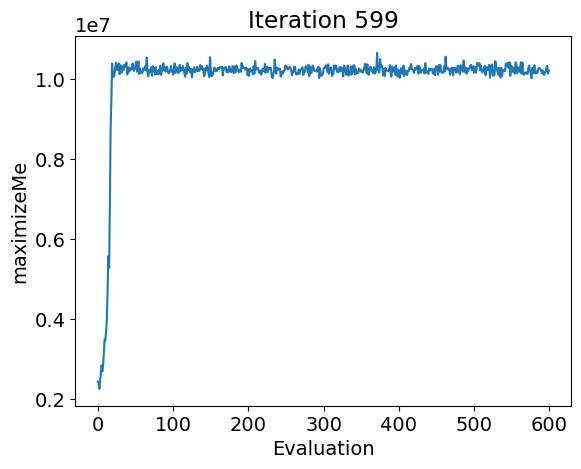

In [16]:
# Can change stopping criterion here, but just 100 runs of the optimizer for now

import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


for i in range(600):
    logger.info("Running Xopt step")

    # THIS IS X.step() but split with code added between #--- lines
    # get number of candidates to generate
    n_generate = X.evaluator.max_workers

    # generate samples and submit to evaluator
    logger.debug(f"Generating {n_generate} candidates")
    new_samples = X.generator.generate(n_generate)
    
    #---
    for j in range(len(new_samples)):
        new_samples[j]["totalNumEvals"] = i
    print(new_samples)
    #---
    if new_samples is not None:
        # Evaluate data
        X.evaluate_data(new_samples)


    #end X.step()
    clear_output(wait=True)
    plt.figure()
    for obj in vocs.objectives.keys():
        plt.plot(X.data[obj])
        plt.xlabel("Evaluation")
        plt.ylabel(obj)
    plt.title(f"Iteration {i}")
    plt.show()


## Save beams 

In [19]:
idx, val, params = X.vocs.select_best(X.data)
params["totalNumEvals"] = i + 1
specificOptimizer(params,
            importedDefaultSettings=importedDefaultSettings,
            masterToleranceScaling=masterToleranceScaling,
            tao=tao,
            PInit=PInit,
            inputBeamFilePathSuffix=inputBeamFilePathSuffix,
            csrTF=csrTF,
            evalElement=evalElement,
            bunchCount=bunchCount,
            saveBeams=True)

{'PDrive_median_x': np.float64(-9.276819057088544e-07), 'PDrive_median_y': np.float64(-3.943128688668333e-07), 'PDrive_median_xp': np.float64(-2.3842583475219366e-07), 'PDrive_median_yp': np.float64(-9.189407424782896e-07), 'PDrive_median_energy': np.float64(10000012887.099998), 'PDrive_sigmaSI90_x': np.float64(1.6821043972071004e-05), 'PDrive_sigmaSI90_y': np.float64(8.317512465183155e-06), 'PDrive_sigmaSI90_z': np.float64(1.3181709702958199e-05), 'PDrive_sigmaSI90_xp': np.float64(4.19899179285569e-05), 'PDrive_sigmaSI90_yp': np.float64(1.8388327821517918e-05), 'PDrive_sigmaSI90_energy': np.float64(26264845.040924184), 'PDrive_emitSI90_x': np.float64(5.489805774798457e-06), 'PDrive_emitSI90_y': np.float64(2.9659328327063746e-06), 'PDrive_norm_emit_x': np.float64(4.301016533873411e-06), 'PDrive_norm_emit_y': np.float64(1.814535984648103e-06), 'PDrive_charge_nC': np.float64(1.5999999999999999), 'PDrive_BMAG_x': np.float64(1.2980103909630545), 'PDrive_BMAG_y': np.float64(1.21746133438752

{'PDrive_median_x': np.float64(-9.276819057088544e-07),
 'PDrive_median_y': np.float64(-3.943128688668333e-07),
 'PDrive_median_xp': np.float64(-2.3842583475219366e-07),
 'PDrive_median_yp': np.float64(-9.189407424782896e-07),
 'PDrive_median_energy': np.float64(10000012887.099998),
 'PDrive_sigmaSI90_x': np.float64(1.6821043972071004e-05),
 'PDrive_sigmaSI90_y': np.float64(8.317512465183155e-06),
 'PDrive_sigmaSI90_z': np.float64(1.3181709702958199e-05),
 'PDrive_sigmaSI90_xp': np.float64(4.19899179285569e-05),
 'PDrive_sigmaSI90_yp': np.float64(1.8388327821517918e-05),
 'PDrive_sigmaSI90_energy': np.float64(26264845.040924184),
 'PDrive_emitSI90_x': np.float64(5.489805774798457e-06),
 'PDrive_emitSI90_y': np.float64(2.9659328327063746e-06),
 'PDrive_norm_emit_x': np.float64(4.301016533873411e-06),
 'PDrive_norm_emit_y': np.float64(1.814535984648103e-06),
 'PDrive_charge_nC': np.float64(1.5999999999999999),
 'PDrive_BMAG_x': np.float64(1.2980103909630545),
 'PDrive_BMAG_y': np.float64